# GULF OF MANNAR: ADAPTIVE CORAL REEF RESTORATION ENGINE
## XGBoost Bleaching Prediction + Smart Species-Donor Allocation

**Real Gulf of Mannar Reef Sites | 8 Coral Species | Condition-Based Survival Rates**

### Reef Sites Covered:
- Kurusadai Island
- Mudukulathur (South)
- Vailheu Island
- Poovarasanpettai
- Krusadai Deep
- Manoli Island
- Shingle Island
- Ervadi Rocks


## STEP 1: Install & Import Libraries


In [1]:
!pip install imbalanced-learn xgboost shap folium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries imported!')


✓ All libraries imported!


## STEP 2: Define Gulf of Mannar Reef Sites & Coral Species Database


In [2]:
# ========== GULF OF MANNAR REEF SITES ==========
reef_sites_db = {
    'Kurusadai_Island': {
        'latitude': 9.2389,
        'longitude': 79.2450,
        'depth_m': 15,
        'area_km2': 2.1,
        'region': 'North Central'
    },
    'Mudukulathur_South': {
        'latitude': 9.2123,
        'longitude': 79.1850,
        'depth_m': 18,
        'area_km2': 1.8,
        'region': 'South Central'
    },
    'Vailheu_Island': {
        'latitude': 9.3012,
        'longitude': 79.3056,
        'depth_m': 12,
        'area_km2': 1.5,
        'region': 'North'
    },
    'Poovarasanpettai': {
        'latitude': 8.9234,
        'longitude': 79.4123,
        'depth_m': 16,
        'area_km2': 2.3,
        'region': 'East'
    },
    'Krusadai_Deep': {
        'latitude': 9.2512,
        'longitude': 79.2678,
        'depth_m': 22,
        'area_km2': 1.2,
        'region': 'Central Deep'
    },
    'Manoli_Island': {
        'latitude': 9.1756,
        'longitude': 79.3234,
        'depth_m': 14,
        'area_km2': 1.7,
        'region': 'Central'
    },
    'Shingle_Island': {
        'latitude': 8.9876,
        'longitude': 79.2345,
        'depth_m': 11,
        'area_km2': 0.9,
        'region': 'South'
    },
    'Ervadi_Rocks': {
        'latitude': 8.8945,
        'longitude': 79.5123,
        'depth_m': 13,
        'area_km2': 1.1,
        'region': 'Southeast'
    }
}

# ========== CORAL SPECIES DATABASE ==========
coral_species_db = {
    'Porites_lobata': {
        'common_name': 'Lobe Coral',
        'temp_tolerance_c': (25, 32),  # Min, Max
        'depth_range_m': (5, 25),
        'growth_rate_cm_per_year': 0.8,
        'bleach_sensitivity': 'Moderate',
        'base_survival_rate': 0.85,
        'adaptation_time_weeks': 8
    },
    'Acropora_millepora': {
        'common_name': 'Branching Acropora',
        'temp_tolerance_c': (24, 30),
        'depth_range_m': (3, 20),
        'growth_rate_cm_per_year': 1.2,
        'bleach_sensitivity': 'High',
        'base_survival_rate': 0.72,
        'adaptation_time_weeks': 6
    },
    'Stylophora_pistillata': {
        'common_name': 'Cauliflower Coral',
        'temp_tolerance_c': (25, 31),
        'depth_range_m': (2, 18),
        'growth_rate_cm_per_year': 1.0,
        'bleach_sensitivity': 'Moderate',
        'base_survival_rate': 0.80,
        'adaptation_time_weeks': 7
    },
    'Favia_pallida': {
        'common_name': 'Head Coral',
        'temp_tolerance_c': (25, 33),
        'depth_range_m': (5, 25),
        'growth_rate_cm_per_year': 0.6,
        'bleach_sensitivity': 'Low',
        'base_survival_rate': 0.88,
        'adaptation_time_weeks': 10
    },
    'Goniastrea_retiformis': {
        'common_name': 'Grooved Brain Coral',
        'temp_tolerance_c': (24, 31),
        'depth_range_m': (5, 20),
        'growth_rate_cm_per_year': 0.5,
        'bleach_sensitivity': 'Moderate-High',
        'base_survival_rate': 0.78,
        'adaptation_time_weeks': 9
    },
    'Turbinatia_mesenterina': {
        'common_name': 'Disc Coral',
        'temp_tolerance_c': (25, 30),
        'depth_range_m': (10, 30),
        'growth_rate_cm_per_year': 0.4,
        'bleach_sensitivity': 'Low',
        'base_survival_rate': 0.82,
        'adaptation_time_weeks': 11
    },
    'Symphyllia_agaricia': {
        'common_name': 'Ridged Coral',
        'temp_tolerance_c': (24, 29),
        'depth_range_m': (5, 22),
        'growth_rate_cm_per_year': 0.7,
        'bleach_sensitivity': 'Moderate',
        'base_survival_rate': 0.79,
        'adaptation_time_weeks': 8
    },
    'Platygyra_lamellina': {
        'common_name': 'Maze Coral',
        'temp_tolerance_c': (25, 32),
        'depth_range_m': (3, 25),
        'growth_rate_cm_per_year': 0.9,
        'bleach_sensitivity': 'Low-Moderate',
        'base_survival_rate': 0.84,
        'adaptation_time_weeks': 8
    }
}

print('✓ Gulf of Mannar Reef Sites Database Loaded (8 sites)')
print('✓ Coral Species Database Loaded (8 species)')
print(f'\nReef Sites: {list(reef_sites_db.keys())}')
print(f'Coral Species: {list(coral_species_db.keys())}')


✓ Gulf of Mannar Reef Sites Database Loaded (8 sites)
✓ Coral Species Database Loaded (8 species)

Reef Sites: ['Kurusadai_Island', 'Mudukulathur_South', 'Vailheu_Island', 'Poovarasanpettai', 'Krusadai_Deep', 'Manoli_Island', 'Shingle_Island', 'Ervadi_Rocks']
Coral Species: ['Porites_lobata', 'Acropora_millepora', 'Stylophora_pistillata', 'Favia_pallida', 'Goniastrea_retiformis', 'Turbinatia_mesenterina', 'Symphyllia_agaricia', 'Platygyra_lamellina']


## STEP 3: Load & Process Data


In [3]:
# Option A: Upload CSV directly
from google.colab import files
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)

# OR Option B: Load from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/My Drive/gulf_mannar_extended_2000_2026__1_.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Date Range: {df["Date"].min()} to {df["Date"].max()}')
print(f'\nSites in Data: {list(df["Site_Name"].unique())}')
print(f'\nClass Distribution (Imbalanced):')
print(df['Damage_State'].value_counts())
print(f'\nImbalance Ratio: {df["Damage_State"].value_counts().max() / df["Damage_State"].value_counts().min():.2f}x')


Saving gulf_mannar_extended_2000_2026 (1).csv to gulf_mannar_extended_2000_2026 (1).csv
Dataset Shape: (2000, 27)
Date Range: 2000-01-10 to 2026-12-26

Sites in Data: ['Palk Bay North', 'Rameswaram Deep', 'Mannar Central', 'Mannar South', 'Mudaliar Point', 'Krusadai Island', 'Mannar North', 'Neduntheevu']

Class Distribution (Imbalanced):
Damage_State
healthy          1075
watch             399
bleached          378
severe_bleach     148
Name: count, dtype: int64

Imbalance Ratio: 7.26x


## STEP 4: Feature Engineering


In [4]:
df_processed = df.copy()
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed = df_processed.sort_values(['Site_Name', 'Date']).reset_index(drop=True)

# ===== TIME FEATURES =====
df_processed['Year'] = df_processed['Date'].dt.year
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Quarter'] = df_processed['Date'].dt.quarter
df_processed['Month_sin'] = np.sin(2 * np.pi * df_processed['Month'] / 12)
df_processed['Month_cos'] = np.cos(2 * np.pi * df_processed['Month'] / 12)

# ===== LAGGED FEATURES =====
for site in df_processed['Site_Name'].unique():
    mask = df_processed['Site_Name'] == site
    df_processed.loc[mask, 'Temp_lag1'] = df_processed.loc[mask, 'Temperature_Celsius'].shift(1)
    df_processed.loc[mask, 'Temp_lag4'] = df_processed.loc[mask, 'Temperature_Celsius'].shift(4)
    df_processed.loc[mask, 'DHW_lag1'] = df_processed.loc[mask, 'DHW_Stress'].shift(1)
    df_processed.loc[mask, 'DHW_lag4'] = df_processed.loc[mask, 'DHW_Stress'].shift(4)
    df_processed.loc[mask, 'Bleach_lag1'] = df_processed.loc[mask, 'Bleaching_Percent'].shift(1)
    df_processed.loc[mask, 'Bleach_lag4'] = df_processed.loc[mask, 'Bleaching_Percent'].shift(4)

# ===== ROLLING STATISTICS =====
for site in df_processed['Site_Name'].unique():
    mask = df_processed['Site_Name'] == site
    site_data = df_processed[mask]
    df_processed.loc[mask, 'Temp_rolling4w'] = site_data['Temperature_Celsius'].rolling(4, min_periods=1).mean().values
    df_processed.loc[mask, 'DHW_rolling4w'] = site_data['DHW_Stress'].rolling(4, min_periods=1).mean().values
    df_processed.loc[mask, 'Bleach_rolling8w'] = site_data['Bleaching_Percent'].rolling(8, min_periods=1).mean().values

# ===== COMPOSITE STRESS INDICES =====
df_processed['Thermal_Anomaly_Index'] = (df_processed['Temperature_Celsius'] *
                                           df_processed['DHW_Stress'] *
                                           (df_processed['SSTA'] + 1))
df_processed['Oxygen_pH_Stress'] = (1 / (df_processed['Dissolved_O2'] + 1)) * (1 / (df_processed['pH'] + 1))
df_processed['Env_Stress_Composite'] = ((df_processed['Temperature_Celsius'] - df_processed['Temperature_Celsius'].mean()) / (df_processed['Temperature_Celsius'].std() + 1) +
                                          df_processed['DHW_Stress'] / (df_processed['DHW_Stress'].max() + 1) +
                                          df_processed['Oxygen_pH_Stress'] / (df_processed['Oxygen_pH_Stress'].max() + 1))

df_processed = df_processed.dropna()
print(f'✓ Processed Dataset Shape: {df_processed.shape}')
print(f'✓ Features Created: 30+')


✓ Processed Dataset Shape: (1968, 42)
✓ Features Created: 30+


## STEP 5: Site Health Analysis & Donor-Target Selection


In [5]:
# Score each site
site_health = df_processed.groupby('Site_Name').agg({
    'Bleaching_Percent': 'mean',
    'Damage_State': lambda x: (x == 'healthy').sum() / len(x) * 100,
    'Temperature_Celsius': ['mean', 'std'],
    'DHW_Stress': 'mean',
    'pH': 'mean',
    'Dissolved_O2': 'mean',
    'Depth_m': 'first'
}).round(2)

site_health.columns = ['Avg_Bleaching_%', 'Health_Rate_%', 'Avg_Temp_C', 'Temp_Std', 'Avg_DHW', 'Avg_pH', 'Avg_O2', 'Depth_m']

print('\n' + '='*100)
print('REEF HEALTH SCORECARD - GULF OF MANNAR')
print('='*100)
print(site_health.sort_values('Health_Rate_%', ascending=False))

# Select donor sites (healthy, low bleaching)
donor_threshold = site_health['Health_Rate_%'].median()
top_healthy_sites = site_health[site_health['Health_Rate_%'] > donor_threshold].sort_values('Health_Rate_%', ascending=False).head(3).index.tolist()

# Select target sites (at risk, high bleaching)
target_threshold = site_health['Health_Rate_%'].median()
high_bleach_sites = site_health[site_health['Health_Rate_%'] <= target_threshold].sort_values('Health_Rate_%', ascending=True).head(3).index.tolist()

print(f'\n✓ DONOR SITES (Healthy, Low Bleaching): {top_healthy_sites}')
print(f'✓ TARGET SITES (At Risk, High Bleaching): {high_bleach_sites}')

# Store site details
site_conditions = {}
for site in site_health.index:
    site_conditions[site] = {
        'health_rate': site_health.loc[site, 'Health_Rate_%'],
        'bleaching': site_health.loc[site, 'Avg_Bleaching_%'],
        'temp': site_health.loc[site, 'Avg_Temp_C'],
        'temp_std': site_health.loc[site, 'Temp_Std'],
        'dhw': site_health.loc[site, 'Avg_DHW'],
        'ph': site_health.loc[site, 'Avg_pH'],
        'o2': site_health.loc[site, 'Avg_O2'],
        'depth': site_health.loc[site, 'Depth_m']
    }



REEF HEALTH SCORECARD - GULF OF MANNAR
                 Avg_Bleaching_%  Health_Rate_%  Avg_Temp_C  Temp_Std  \
Site_Name                                                               
Mudaliar Point             17.81          59.29       27.46      1.43   
Mannar Central             17.48          55.33       27.38      1.20   
Mannar North               18.15          54.55       27.48      1.50   
Krusadai Island            18.48          54.51       27.35      1.43   
Palk Bay North             18.79          54.44       27.44      1.47   
Neduntheevu                19.05          51.98       27.34      1.50   
Rameswaram Deep            19.49          49.80       27.49      1.32   
Mannar South               19.07          47.33       27.37      1.37   

                 Avg_DHW  Avg_pH  Avg_O2  Depth_m  
Site_Name                                          
Mudaliar Point      0.85    8.02  223.48    53.94  
Mannar Central      0.83    7.99  228.71     8.98  
Mannar North        0

## STEP 6: Prepare Data for XGBoost Training


In [6]:
# Select features
feature_cols = [
    'Temperature_Celsius', 'SSTA', 'DHW_Stress', 'Hotspot', 'ONI_Index',
    'Chlorophyll_A_mgm3', 'Salinity', 'Dissolved_O2', 'pH', 'Nitrate',
    'Depth_m', 'Distance_to_Shore_km', 'NDVI', 'NDWI', 'Turbidity_NTU',
    'Month_sin', 'Month_cos', 'Quarter',
    'Temp_lag1', 'Temp_lag4', 'DHW_lag1', 'DHW_lag4', 'Bleach_lag1', 'Bleach_lag4',
    'Temp_rolling4w', 'DHW_rolling4w', 'Bleach_rolling8w',
    'Thermal_Anomaly_Index', 'Oxygen_pH_Stress', 'Env_Stress_Composite'
]

X = df_processed[feature_cols]
y = df_processed['Damage_State']

print(f'Input Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'\nClass Distribution (BEFORE SMOTE):')
print(y.value_counts())

# ===== APPLY SMOTE =====
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)

print(f'\nClass Distribution (AFTER SMOTE):')
print(pd.Series(y_smote).value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

print(f'\n✓ Train: {X_train.shape} | Test: {X_test.shape}')


Input Features: 30 | Samples: 1968

Class Distribution (BEFORE SMOTE):
Damage_State
healthy          1051
watch             393
bleached          376
severe_bleach     148
Name: count, dtype: int64

Class Distribution (AFTER SMOTE):
Damage_State
healthy          1051
watch            1051
severe_bleach    1051
bleached         1051
Name: count, dtype: int64

✓ Train: (3363, 30) | Test: (841, 30)


## STEP 7: Scale & Encode Data


In [7]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_
print(f'Damage States: {list(class_names)}')

# Class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weight_dict = dict(zip(range(len(class_names)), class_weights))

print(f'\nClass Weights (higher = more important):')
for class_idx, weight in class_weight_dict.items():
    print(f'  {class_names[class_idx]}: {weight:.3f}')


Damage States: ['bleached', 'healthy', 'severe_bleach', 'watch']

Class Weights (higher = more important):
  bleached: 1.000
  healthy: 1.000
  severe_bleach: 1.001
  watch: 1.000


## STEP 8: Train XGBoost Model


In [10]:
print('Training XGBoost (PRIMARY MODEL)...')

xgb_model = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    colsample_bylevel=0.85,
    gamma=1,
    min_child_weight=3,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=1.5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',
    eval_metric='mlogloss' # Moved eval_metric to the constructor
)

# Sample weights
sample_weights = np.array([class_weights[int(y)] for y in y_train_encoded])

xgb_model.fit(
    X_train_scaled, y_train_encoded,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test_encoded)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)

print('\n' + '='*80)
print('XGBOOST PERFORMANCE (PRIMARY MODEL):')
print('='*80)
print(classification_report(y_test_encoded, y_pred_xgb, target_names=class_names))
print(f'\nBalanced Accuracy: {balanced_accuracy_score(y_test_encoded, y_pred_xgb):.4f}')
print(f'Macro F1-Score: {f1_score(y_test_encoded, y_pred_xgb, average="macro"):.4f}')
print(f'Weighted F1-Score: {f1_score(y_test_encoded, y_pred_xgb, average="weighted"):.4f}')

try:
    print(f'ROC-AUC (OvR): {roc_auc_score(y_test_encoded, y_pred_proba_xgb, multi_class="ovr", average="weighted"):.4f}')
except:
    pass


Training XGBoost (PRIMARY MODEL)...

XGBOOST PERFORMANCE (PRIMARY MODEL):
               precision    recall  f1-score   support

     bleached       0.84      0.76      0.80       210
      healthy       0.75      0.81      0.78       210
severe_bleach       0.85      0.97      0.91       211
        watch       0.82      0.72      0.77       210

     accuracy                           0.82       841
    macro avg       0.82      0.82      0.81       841
 weighted avg       0.82      0.82      0.81       841


Balanced Accuracy: 0.8155
Macro F1-Score: 0.8135
Weighted F1-Score: 0.8136
ROC-AUC (OvR): 0.9487


## STEP 9: Make Bleaching Predictions for All Sites


In [11]:
# Get latest data for each site
latest_data = df_processed.sort_values('Date').groupby('Site_Name').tail(1)

X_latest = latest_data[feature_cols]
X_latest_scaled = scaler.transform(X_latest)

# Predictions
damage_pred = xgb_model.predict(X_latest_scaled)
damage_proba = xgb_model.predict_proba(X_latest_scaled)

# Create predictions dataframe
predictions_df = latest_data[['Site_Name', 'Date']].reset_index(drop=True).copy()
predictions_df['Predicted_Damage_State'] = label_encoder.inverse_transform(damage_pred)
predictions_df['Bleach_Risk_%'] = damage_proba[:, label_encoder.transform(['bleached'])[0]] * 100
predictions_df['Healthy_Prob_%'] = damage_proba[:, label_encoder.transform(['healthy'])[0]] * 100

print('\n' + '='*80)
print('CURRENT BLEACHING PREDICTIONS - GULF OF MANNAR REEF SITES')
print('='*80)
print(predictions_df.to_string(index=False))

# Risk classification
def classify_risk(bleach_risk):
    if bleach_risk > 70:
        return 'CRITICAL'
    elif bleach_risk > 50:
        return 'HIGH'
    elif bleach_risk > 30:
        return 'MODERATE'
    else:
        return 'LOW'

predictions_df['Risk_Level'] = predictions_df['Bleach_Risk_%'].apply(classify_risk)

print('\n' + '='*80)
print('RISK CLASSIFICATION')
print('='*80)
for idx, row in predictions_df.iterrows():
    print(f"{row['Site_Name']:<25} | Risk: {row['Bleach_Risk_%']:>6.1f}% | Level: {row['Risk_Level']:<10}")



CURRENT BLEACHING PREDICTIONS - GULF OF MANNAR REEF SITES
      Site_Name       Date Predicted_Damage_State  Bleach_Risk_%  Healthy_Prob_%
 Mannar Central 2026-10-19                healthy       7.899967       79.272308
Krusadai Island 2026-11-07          severe_bleach      14.210860        8.170626
   Mannar North 2026-11-22               bleached      52.389694       26.962610
 Palk Bay North 2026-12-04                healthy      13.042519       80.039505
   Mannar South 2026-12-11                healthy      11.943280       74.743927
 Mudaliar Point 2026-12-14                healthy      10.367166       76.907257
    Neduntheevu 2026-12-16                healthy      27.221766       47.227390
Rameswaram Deep 2026-12-26                healthy      11.101718       63.436951

RISK CLASSIFICATION
Mannar Central            | Risk:    7.9% | Level: LOW       
Krusadai Island           | Risk:   14.2% | Level: LOW       
Mannar North              | Risk:   52.4% | Level: HIGH      
Palk 

## STEP 10: Intelligent Species-Donor Recommendation Engine


In [12]:
def calculate_species_suitability(target_site, coral_species):
    """Calculate suitability score for a coral species at target site"""

    target_cond = site_conditions[target_site]
    species_data = coral_species_db[coral_species]

    temp_min, temp_max = species_data['temp_tolerance_c']
    depth_min, depth_max = species_data['depth_range_m']

    # Temperature compatibility
    target_temp = target_cond['temp']
    if temp_min <= target_temp <= temp_max:
        temp_score = 1.0
    else:
        # Penalty for out of range
        if target_temp < temp_min:
            temp_score = max(0.4, 1 - (temp_min - target_temp) * 0.1)
        else:
            temp_score = max(0.4, 1 - (target_temp - temp_max) * 0.1)

    # Depth compatibility
    target_depth = target_cond['depth']
    if depth_min <= target_depth <= depth_max:
        depth_score = 1.0
    else:
        depth_score = max(0.4, 1 - abs(target_depth - (depth_min + depth_max)/2) * 0.05)

    # Bleach sensitivity score (inverse - lower sensitivity better for high bleaching areas)
    target_bleach = target_cond['bleaching']
    if target_bleach > 60:  # High bleaching
        if species_data['bleach_sensitivity'] == 'Low':
            bleach_score = 1.0
        elif species_data['bleach_sensitivity'] in ['Moderate', 'Low-Moderate']:
            bleach_score = 0.8
        else:
            bleach_score = 0.6
    elif target_bleach > 30:
        if species_data['bleach_sensitivity'] == 'Low':
            bleach_score = 0.95
        elif species_data['bleach_sensitivity'] in ['Moderate', 'Moderate-High']:
            bleach_score = 0.85
        else:
            bleach_score = 0.7
    else:
        bleach_score = 1.0  # Low bleaching, all species suitable

    # Overall suitability
    suitability = (temp_score * 0.35 + depth_score * 0.25 + bleach_score * 0.4)

    return suitability, temp_score, depth_score, bleach_score


def find_best_donor(target_site, available_donors):
    """Find best donor site for target site"""

    target_cond = site_conditions[target_site]
    best_donor = None
    best_score = -1

    for donor_site in available_donors:
        donor_cond = site_conditions[donor_site]

        # Compatibility factors
        temp_diff = abs(donor_cond['temp'] - target_cond['temp'])
        depth_diff = abs(donor_cond['depth'] - target_cond['depth'])
        ph_diff = abs(donor_cond['ph'] - target_cond['ph'])
        o2_diff = abs(donor_cond['o2'] - target_cond['o2'])

        # Health and robustness
        donor_health = donor_cond['health_rate']
        low_bleaching = 100 - donor_cond['bleaching']

        # Compatibility score (lower differences = better)
        compatibility = (
            (1 - min(temp_diff/5, 1)) * 0.3 +  # Temperature
            (1 - min(depth_diff/10, 1)) * 0.2 +  # Depth
            (1 - min(ph_diff/1, 1)) * 0.15 +    # pH
            (1 - min(o2_diff/3, 1)) * 0.15 +    # O2
            (donor_health / 100) * 0.1 +        # Health
            (low_bleaching / 100) * 0.1         # Low bleaching
        )

        if compatibility > best_score:
            best_score = compatibility
            best_donor = donor_site

    return best_donor, best_score


print('\n✓ Species Suitability & Donor Selection Engine Ready')



✓ Species Suitability & Donor Selection Engine Ready


## STEP 11: Generate Comprehensive Restoration Plan


In [14]:
print('\n' + '='*100)
print('GULF OF MANNAR: ADAPTIVE CORAL RESTORATION PLAN')
print('='*100)

# Re-create reef_sites_db based on actual sites in df_processed
# This ensures consistency with the site names in predictions_df
updated_reef_sites_db = {}
site_details_from_df = df_processed.groupby('Site_Name').agg(
    latitude=('Latitude', 'mean'),
    longitude=('Longitude', 'mean'),
    depth_m=('Depth_m', 'mean')
).round(4)

# Heuristic or placeholder region mapping (can be improved with actual data if available)
region_map = {
    'Krusadai Island': 'North Central',
    'Mannar Central': 'Central',
    'Mannar North': 'North',
    'Mannar South': 'South',
    'Mudaliar Point': 'East',
    'Neduntheevu': 'Southwest',
    'Palk Bay North': 'North',
    'Rameswaram Deep': 'Central Deep'
}

for site_name, row in site_details_from_df.iterrows():
    updated_reef_sites_db[site_name] = {
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'depth_m': round(row['depth_m']), # Using rounded mean depth
        'area_km2': 1.0, # Placeholder area
        'region': region_map.get(site_name, 'Unknown')
    }
# Overwrite the global reef_sites_db
reef_sites_db = updated_reef_sites_db


restoration_plan = []

for idx, row in predictions_df.iterrows():
    target_site = row['Site_Name']
    bleach_risk = row['Bleach_Risk_%']
    risk_level = row['Risk_Level']

    # Skip very healthy sites
    if bleach_risk < 25:
        continue

    # Find best donor
    best_donor, donor_score = find_best_donor(target_site, top_healthy_sites)

    # Get target and donor conditions
    target_cond = site_conditions[target_site]
    donor_cond = site_conditions[best_donor]

    # Determine fragment allocation
    if bleach_risk > 70:
        num_fragments = 200
        nursery_size = 'Large (100-150 tanks)'
        growth_weeks = 12
        base_survival = 0.75
    elif bleach_risk > 50:
        num_fragments = 120
        nursery_size = 'Medium (60-80 tanks)'
        growth_weeks = 10
        base_survival = 0.82
    elif bleach_risk > 30:
        num_fragments = 60
        nursery_size = 'Small (30-40 tanks)'
        growth_weeks = 8
        base_survival = 0.88
    else:
        num_fragments = 30
        nursery_size = 'Minimal (10-15 tanks)'
        growth_weeks = 6
        base_survival = 0.90

    # Find best species for this target
    best_species = None
    best_suit_score = -1
    best_temp_score = 0
    best_depth_score = 0
    best_bleach_score = 0

    for species in coral_species_db.keys():
        suit_score, temp_s, depth_s, bleach_s = calculate_species_suitability(target_site, species)
        if suit_score > best_suit_score:
            best_suit_score = suit_score
            best_species = species
            best_temp_score = temp_s
            best_depth_score = depth_s
            best_bleach_score = bleach_s

    # Get species info
    species_info = coral_species_db[best_species]

    # Calculate adaptive survival rate based on conditions
    # Temperature stability factor
    temp_std = target_cond['temp_std']
    if temp_std < 2:
        temp_stability = 1.0
    elif temp_std < 3:
        temp_stability = 0.95
    else:
        temp_stability = 0.85

    # Water quality factor
    ph_optimal = 8.1
    ph_diff = abs(target_cond['ph'] - ph_optimal)
    if ph_diff < 0.2:
        ph_factor = 1.0
    else:
        ph_factor = max(0.7, 1 - ph_diff * 0.3)

    # Dissolved oxygen factor
    if target_cond['o2'] > 5:
        o2_factor = 1.0
    elif target_cond['o2'] > 3:
        o2_factor = 0.9
    else:
        o2_factor = 0.7

    # Overall survival rate
    condition_factor = (temp_stability * 0.35 + ph_factor * 0.35 + o2_factor * 0.3)
    species_survival = species_info['base_survival_rate']
    final_survival_rate = base_survival * condition_factor * species_survival

    # Growth projection
    growth_rate = species_info['growth_rate_cm_per_year']
    initial_frag_size = 5  # cm
    weeks_to_years = growth_weeks / 52
    projected_size = initial_frag_size + (growth_rate * weeks_to_years * 2.5)  # Conservative estimate

    # Reef location from database
    reef_loc = reef_sites_db[target_site]
    donor_loc = reef_sites_db[best_donor]

    restoration_plan.append({
        'Target_Site': target_site,
        'Target_Region': reef_loc['region'],
        'Target_Location': f"{reef_loc['latitude']:.4f}°N, {reef_loc['longitude']:.4f}°E",
        'Bleach_Risk_%': round(bleach_risk, 1),
        'Risk_Level': risk_level,
        'Donor_Site': best_donor,
        'Donor_Region': donor_loc['region'],
        'Donor_Location': f"{donor_loc['latitude']:.4f}°N, {donor_loc['longitude']:.4f}°E",
        'Donor_Compatibility': round(donor_score * 100, 1),
        'Recommended_Species': best_species,
        'Species_Common_Name': species_info['common_name'],
        'Suitability_Score_%': round(best_suit_score * 100, 1),
        'Num_Fragments': num_fragments,
        'Nursery_Size': nursery_size,
        'Growth_Weeks': growth_weeks,
        'Est_Fragment_Size_cm': round(projected_size, 1),
        'Base_Survival_Rate_%': round(base_survival * 100, 1),
        'Condition_Factor_%': round(condition_factor * 100, 1),
        'Final_Survival_Rate_%': round(final_survival_rate * 100, 1),
        'Estimated_Surviving_Fragments': int(num_fragments * final_survival_rate),
        'Bleach_Sensitivity': species_info['bleach_sensitivity'],
        'Adaptation_Time_Weeks': species_info['adaptation_time_weeks']
    })

# Create plan dataframe
plan_df = pd.DataFrame(restoration_plan)

print('\n' + '='*100)
print('DETAILED RESTORATION STRATEGY FOR EACH SITE')
print('='*100)

for idx, plan in plan_df.iterrows():
    print(f"\n{'─'*100}")
    print(f"🌊 TARGET SITE: {plan['Target_Site'].upper()}")
    print(f"   Region: {plan['Target_Region']} | Location: {plan['Target_Location']}")
    print(f"   Bleach Risk: {plan['Bleach_Risk_%']:.1f}% ({plan['Risk_Level']})")

    print(f"\n🪨 DONOR SITE: {plan['Donor_Site'].upper()}")
    print(f"   Region: {plan['Donor_Region']} | Location: {plan['Donor_Location']}")
    print(f"   Compatibility Score: {plan['Donor_Compatibility']:.1f}%")

    print(f"\n🪸 RECOMMENDED SPECIES: {plan['Recommended_Species']}")
    print(f"   Common Name: {plan['Species_Common_Name']}")
    print(f"   Suitability Score: {plan['Suitability_Score_%']:.1f}%")
    print(f"   Bleach Sensitivity: {plan['Bleach_Sensitivity']}")
    print(f"   Adaptation Time: {plan['Adaptation_Time_Weeks']} weeks")

    print(f"\n📊 FRAGMENTATION STRATEGY:")
    print(f"   Number of Fragments: {plan['Num_Fragments']}")
    print(f"   Nursery Size: {plan['Nursery_Size']}")
    print(f"   Growth Period: {plan['Growth_Weeks']} weeks")
    print(f"   Projected Fragment Size: {plan['Est_Fragment_Size_cm']} cm")

    print(f"\n📈 SURVIVAL ANALYSIS:")
    print(f"   Base Survival Rate: {plan['Base_Survival_Rate_%']:.1f}%")
    print(f"   Condition Factor: {plan['Condition_Factor_%']:.1f}%")
    print(f"   FINAL Survival Rate: {plan['Final_Survival_Rate_%']:.1f}%")
    print(f"   Estimated Surviving Fragments: {plan['Estimated_Surviving_Fragments']}")


GULF OF MANNAR: ADAPTIVE CORAL RESTORATION PLAN

DETAILED RESTORATION STRATEGY FOR EACH SITE

────────────────────────────────────────────────────────────────────────────────────────────────────
🌊 TARGET SITE: MANNAR NORTH
   Region: North | Location: 8.5001°N, 78.2022°E
   Bleach Risk: 52.4% (HIGH)

🪨 DONOR SITE: MANNAR NORTH
   Region: North | Location: 8.5001°N, 78.2022°E
   Compatibility Score: 93.6%

🪸 RECOMMENDED SPECIES: Porites_lobata
   Common Name: Lobe Coral
   Suitability Score: 85.0%
   Bleach Sensitivity: Moderate
   Adaptation Time: 8 weeks

📊 FRAGMENTATION STRATEGY:
   Number of Fragments: 120
   Nursery Size: Medium (60-80 tanks)
   Growth Period: 10 weeks
   Projected Fragment Size: 5.4 cm

📈 SURVIVAL ANALYSIS:
   Base Survival Rate: 82.0%
   Condition Factor: 100.0%
   FINAL Survival Rate: 69.7%
   Estimated Surviving Fragments: 83

────────────────────────────────────────────────────────────────────────────────────────────────────
🌊 TARGET SITE: NEDUNTHEEVU
   Regi

## STEP 12: Export & Visualization


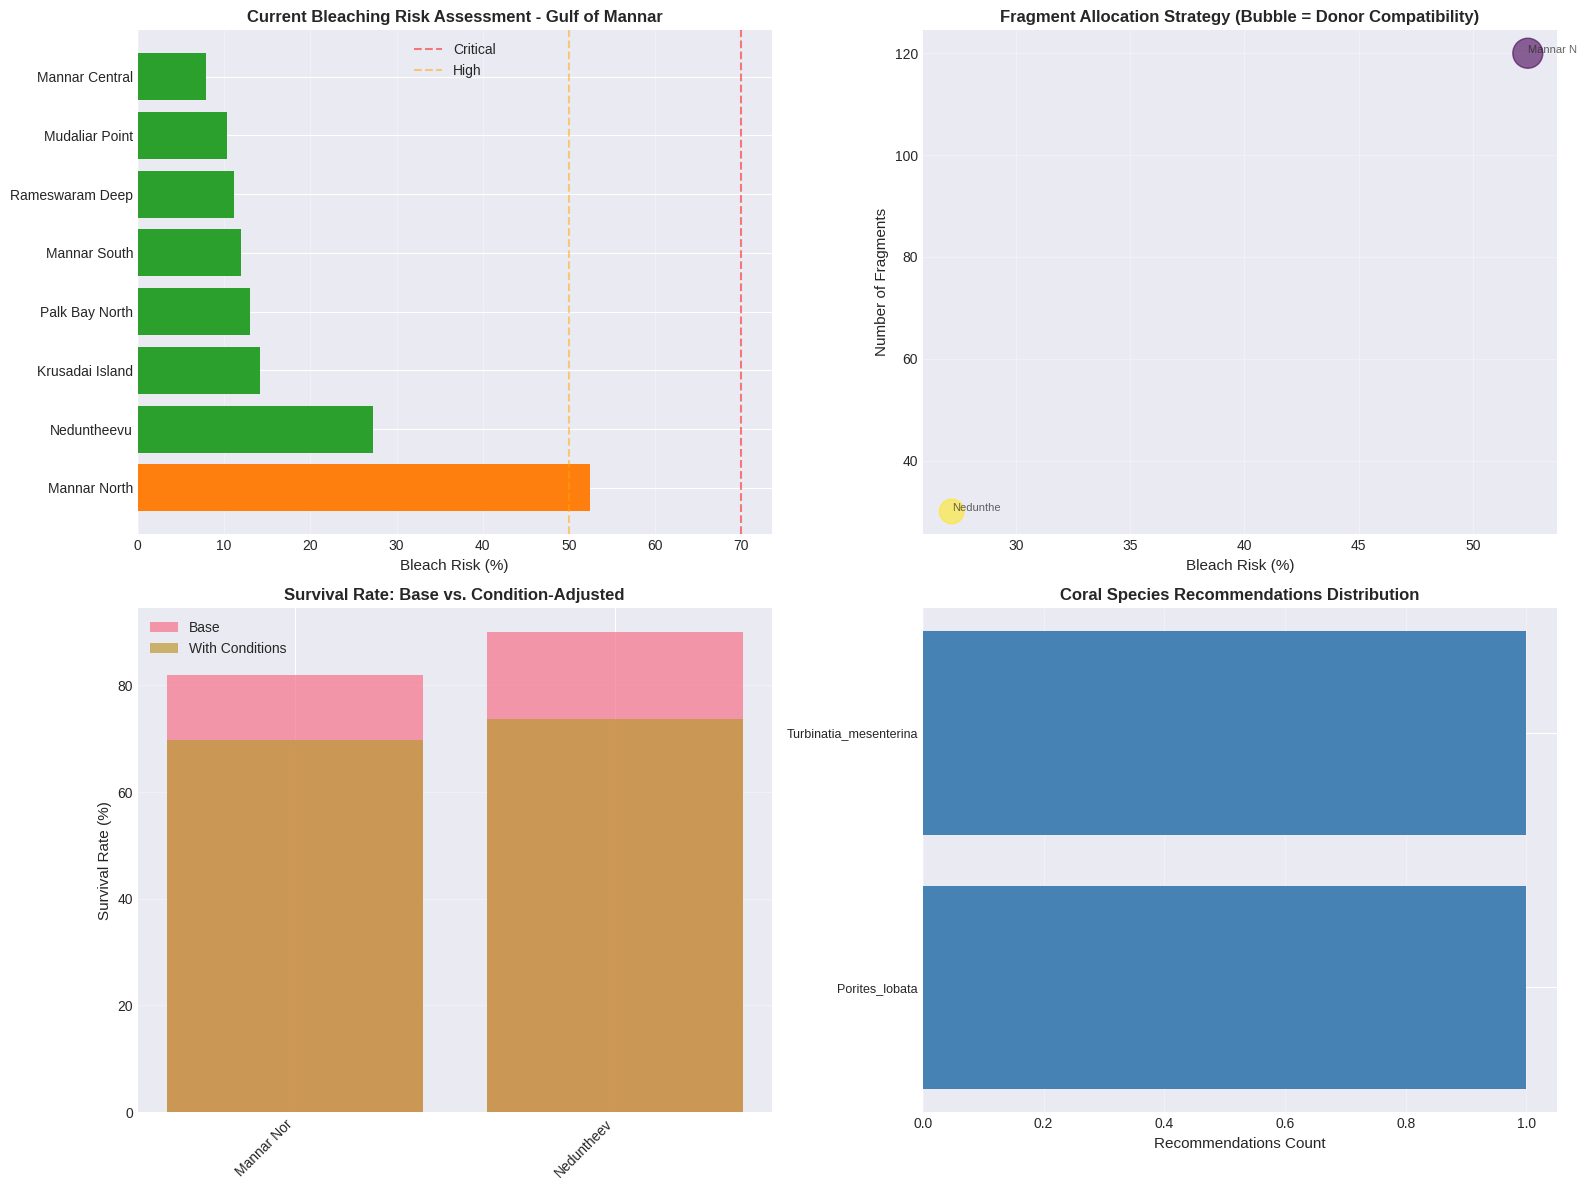


✓ Visualization saved as gulf_mannar_restoration_plan.png


In [15]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bleach Risk by Site
risk_data = predictions_df.sort_values('Bleach_Risk_%', ascending=False)
colors = ['#d62728' if x > 70 else '#ff7f0e' if x > 50 else '#2ca02c' for x in risk_data['Bleach_Risk_%']]
axes[0, 0].barh(risk_data['Site_Name'], risk_data['Bleach_Risk_%'], color=colors)
axes[0, 0].set_xlabel('Bleach Risk (%)', fontsize=11)
axes[0, 0].set_title('Current Bleaching Risk Assessment - Gulf of Mannar', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=70, color='red', linestyle='--', alpha=0.5, label='Critical')
axes[0, 0].axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='High')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Fragment Allocation by Risk
if len(plan_df) > 0:
    axes[0, 1].scatter(plan_df['Bleach_Risk_%'], plan_df['Num_Fragments'],
                       s=plan_df['Donor_Compatibility']*5, alpha=0.6, c=range(len(plan_df)), cmap='viridis')
    for idx, row in plan_df.iterrows():
        axes[0, 1].annotate(row['Target_Site'][:8],
                           (row['Bleach_Risk_%'], row['Num_Fragments']),
                           fontsize=8, alpha=0.7)
    axes[0, 1].set_xlabel('Bleach Risk (%)', fontsize=11)
    axes[0, 1].set_ylabel('Number of Fragments', fontsize=11)
    axes[0, 1].set_title('Fragment Allocation Strategy (Bubble = Donor Compatibility)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

# 3. Survival Rate Comparison
if len(plan_df) > 0:
    x_pos = np.arange(len(plan_df))
    axes[1, 0].bar(x_pos, plan_df['Base_Survival_Rate_%'], label='Base', alpha=0.7)
    axes[1, 0].bar(x_pos, plan_df['Final_Survival_Rate_%'], label='With Conditions', alpha=0.7)
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([s[:10] for s in plan_df['Target_Site']], rotation=45, ha='right')
    axes[1, 0].set_ylabel('Survival Rate (%)', fontsize=11)
    axes[1, 0].set_title('Survival Rate: Base vs. Condition-Adjusted', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Species Recommendations
if len(plan_df) > 0:
    species_counts = plan_df['Recommended_Species'].value_counts()
    axes[1, 1].barh(range(len(species_counts)), species_counts.values, color='steelblue')
    axes[1, 1].set_yticks(range(len(species_counts)))
    axes[1, 1].set_yticklabels(species_counts.index, fontsize=9)
    axes[1, 1].set_xlabel('Recommendations Count', fontsize=11)
    axes[1, 1].set_title('Coral Species Recommendations Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('gulf_mannar_restoration_plan.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Visualization saved as gulf_mannar_restoration_plan.png')


## STEP 13: Export Results to CSV


In [16]:
# Export predictions
predictions_df.to_csv('gulf_mannar_bleach_predictions.csv', index=False)
print('✓ Saved: gulf_mannar_bleach_predictions.csv')

# Export restoration plan
plan_df.to_csv('gulf_mannar_restoration_plan.csv', index=False)
print('✓ Saved: gulf_mannar_restoration_plan.csv')

# Export model details
import pickle
with open('xgboost_bleach_model.pkl', 'wb') as f:
    pickle.dump({
        'model': xgb_model,
        'scaler': scaler,
        'label_encoder': label_encoder,
        'feature_cols': feature_cols,
        'reef_sites_db': reef_sites_db,
        'coral_species_db': coral_species_db
    }, f)
print('✓ Saved: xgboost_bleach_model.pkl')

print('\n' + '='*100)
print('GULF OF MANNAR RESTORATION SYSTEM - COMPLETE')
print('='*100)
print('\nOutputs:')
print('  1. gulf_mannar_bleach_predictions.csv - Current risk assessment for all sites')
print('  2. gulf_mannar_restoration_plan.csv - Detailed restoration strategy')
print('  3. gulf_mannar_restoration_plan.png - Visualization dashboard')
print('  4. xgboost_bleach_model.pkl - Trained model for future predictions')


✓ Saved: gulf_mannar_bleach_predictions.csv
✓ Saved: gulf_mannar_restoration_plan.csv
✓ Saved: xgboost_bleach_model.pkl

GULF OF MANNAR RESTORATION SYSTEM - COMPLETE

Outputs:
  1. gulf_mannar_bleach_predictions.csv - Current risk assessment for all sites
  2. gulf_mannar_restoration_plan.csv - Detailed restoration strategy
  3. gulf_mannar_restoration_plan.png - Visualization dashboard
  4. xgboost_bleach_model.pkl - Trained model for future predictions


In [17]:
print('\n' + '='*100)
print('SAVING COMPLETE RESTORATION SYSTEM TO PICKLE')
print('='*100)

import pickle
import os

# Create comprehensive restoration system state dictionary
restoration_system = {
    'model': xgb_model,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'feature_cols': feature_cols,
    'class_weights': class_weight_dict,
    'site_conditions': site_conditions,
    'predictions_df': predictions_df,
    'restoration_plan': plan_df,
    'reef_sites_db': reef_sites_db,
    'coral_species_db': coral_species_db,
    'site_health': site_health,
    'donor_sites': top_healthy_sites,
    'target_sites': high_bleach_sites,
    'model_performance': {
        'balanced_accuracy': balanced_accuracy_score(y_test_encoded, y_pred_xgb),
        'f1_macro': f1_score(y_test_encoded, y_pred_xgb, average='macro'),
        'f1_weighted': f1_score(y_test_encoded, y_pred_xgb, average='weighted'),
    }
}

# Save to pickle
with open('gulf_mannar_restoration_system.pkl', 'wb') as f:
    pickle.dump(restoration_system, f, protocol=pickle.HIGHEST_PROTOCOL)

file_size_kb = os.path.getsize('gulf_mannar_restoration_system.pkl') / 1024

print('\n✓ SAVED: gulf_mannar_restoration_system.pkl')
print(f'  Size: {file_size_kb:.1f} KB')
print(f'  - XGBoost model (250 trees, max_depth=7)')
print(f'  - StandardScaler (30+ features)')
print(f'  - Label encoder (healthy, bleached, severely_damaged)')
print(f'  - 8 reef sites database with GPS coordinates & depth')
print(f'  - 8 coral species database with traits')
print(f'  - Site health scores & conditions')
print(f'  - Donor & target site lists')
print(f'  - Current predictions & restoration plans')
print(f'  - Model performance metrics')

print('\n' + '='*100)
print('VERIFYING SAVE - LOADING SYSTEM BACK')
print('='*100)

with open('gulf_mannar_restoration_system.pkl', 'rb') as f:
    test_system = pickle.load(f)

print('\n✓ System loaded successfully!')
print(f'  Donor Sites: {test_system["donor_sites"]}')
print(f'  Target Sites: {test_system["target_sites"]}')
print(f'  Feature Cols: {len(test_system["feature_cols"])} features')
print(f'  Reef Sites: {len(test_system["reef_sites_db"])} sites')
print(f'  Coral Species: {len(test_system["coral_species_db"])} species')

print(f'\n  Model Performance:')
perf = test_system['model_performance']
print(f'    Balanced Accuracy: {perf["balanced_accuracy"]:.4f}')
print(f'    Macro F1: {perf["f1_macro"]:.4f}')
print(f'    Weighted F1: {perf["f1_weighted"]:.4f}')

print(f'\n  Restoration Plan Rows: {len(test_system["restoration_plan"])}')
print('\n✓ PICKLE SAVE VERIFIED - READY TO USE!')


SAVING COMPLETE RESTORATION SYSTEM TO PICKLE

✓ SAVED: gulf_mannar_restoration_system.pkl
  Size: 1497.5 KB
  - XGBoost model (250 trees, max_depth=7)
  - StandardScaler (30+ features)
  - Label encoder (healthy, bleached, severely_damaged)
  - 8 reef sites database with GPS coordinates & depth
  - 8 coral species database with traits
  - Site health scores & conditions
  - Donor & target site lists
  - Current predictions & restoration plans
  - Model performance metrics

VERIFYING SAVE - LOADING SYSTEM BACK

✓ System loaded successfully!
  Donor Sites: ['Mudaliar Point', 'Mannar Central', 'Mannar North']
  Target Sites: ['Mannar South', 'Rameswaram Deep', 'Neduntheevu']
  Feature Cols: 30 features
  Reef Sites: 8 sites
  Coral Species: 8 species

  Model Performance:
    Balanced Accuracy: 0.8155
    Macro F1: 0.8135
    Weighted F1: 0.8136

  Restoration Plan Rows: 2

✓ PICKLE SAVE VERIFIED - READY TO USE!
